# Módulo 3 — Análisis Exploratorio: IRAG Inusitada
**Fuentes:** SIVIGILA · CHIRPS · NOAA ONI  
**Período:** 2018–2023 · **Municipios:** 1121

Contenido:
1. Carga y diagnóstico general
2. Distribución temporal de casos (nacional)
3. Distribución espacial — municipios con más casos
4. Casos por fase ONI
5. Relación visual precipitación vs casos
6. Verificación de calidad de datos

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Configuración ─────────────────────────────────────────────────────────
DATASET_PATH = (
    r"C:\Users\laura\OneDrive\TESIS\ETL_LauraChacon"
    r"\ETL_code\dashboard_3\processed\join\dataset_irag_2018_2024.parquet"
)

COLORES = {
    "irag":   "#6B3A9E",
    "precip": "#185FA5",
    "oni":    "#333333",
    "nino":   "#E24B4A",
    "nina":   "#185FA5",
    "neutral":"#6B9E6B",
}

NOMBRES_MESES = ["Ene","Feb","Mar","Abr","May","Jun",
                 "Jul","Ago","Sep","Oct","Nov","Dic"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10,
})

print("Librerías cargadas")

Librerías cargadas


## 1. Carga y diagnóstico general

In [9]:
df = pd.read_parquet(DATASET_PATH)
df["date"] = pd.to_datetime(df["date"])
df["mes"]  = df["date"].dt.month
df["anio"] = df["date"].dt.year

# Clasificar fase ONI
def fase_oni(v):
    if pd.isna(v):    return "Sin dato"
    if v >=  0.5:     return "El Niño"
    if v <= -0.5:     return "La Niña"
    return "Neutral"

df["fase_oni"] = df["value_oni"].apply(fase_oni)

print("=" * 55)
print("DIAGNÓSTICO GENERAL")
print("=" * 55)
print(f"Registros totales      : {len(df):,}")
print(f"Municipios             : {df['muni_code'].nunique():,}")
print(f"Período                : {df['date'].min().strftime('%b %Y')} – {df['date'].max().strftime('%b %Y')}")
print(f"Casos totales IRAG     : {df['casos'].sum():,}")
print(f"Meses con casos > 0    : {(df['casos'] > 0).sum():,} ({(df['casos'] > 0).mean()*100:.1f}%)")
print(f"Municipios con casos   : {df[df['casos'] > 0]['muni_code'].nunique():,}")
print(f"Municipios sin casos   : {df[df['casos'] == 0]['muni_code'].nunique():,}")
print(f"NaN en precipitación   : {df['precip_mean_mm'].isna().sum():,}")
print(f"NaN en ONI             : {df['value_oni'].isna().sum():,}")
print()
print("Casos por fase ONI:")
print(df.groupby("fase_oni")["casos"].agg(["sum","mean","count"])
        .rename(columns={"sum":"total","mean":"media","count":"registros"})
        .round(2))
print()
df.head()

DIAGNÓSTICO GENERAL
Registros totales      : 94,164
Municipios             : 1,121
Período                : Jan 2018 – Dec 2024
Casos totales IRAG     : 20,552
Meses con casos > 0    : 5,591 (5.9%)
Municipios con casos   : 851
Municipios sin casos   : 1,121
NaN en precipitación   : 0
NaN en ONI             : 0

Casos por fase ONI:
          total  media  registros
fase_oni                         
El Niño    4875   0.16      30267
La Niña   12225   0.38      32509
Neutral    3452   0.11      31388



,date,muni_code,anio,mes,precip_mean_mm,precip_min,precip_max,std_dev,n_pixels,cod_eve,casos,value_oni,fase_oni
0,2018-01-01,05001,2018,1,120.760429,68.837364,158.311066,23.338869,24,348,1,-0.77,La Niña
1,2018-02-01,05001,2018,2,56.073654,43.314682,68.918900,7.345044,24,348,1,-0.71,La Niña
2,2018-03-01,05001,2018,3,98.153664,69.992691,120.212929,11.973615,24,348,0,-0.57,La Niña
3,2018-04-01,05001,2018,4,250.619995,208.216278,297.751709,20.432331,24,348,0,-0.39,Neutral
4,2018-05-01,05001,2018,5,329.347595,260.304810,403.612976,37.042576,24,348,5,-0.13,Neutral


## 2. Distribución temporal de casos (nivel nacional)

C:\Users\laura\AppData\Local\Temp\ipykernel_22072\1054200776.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


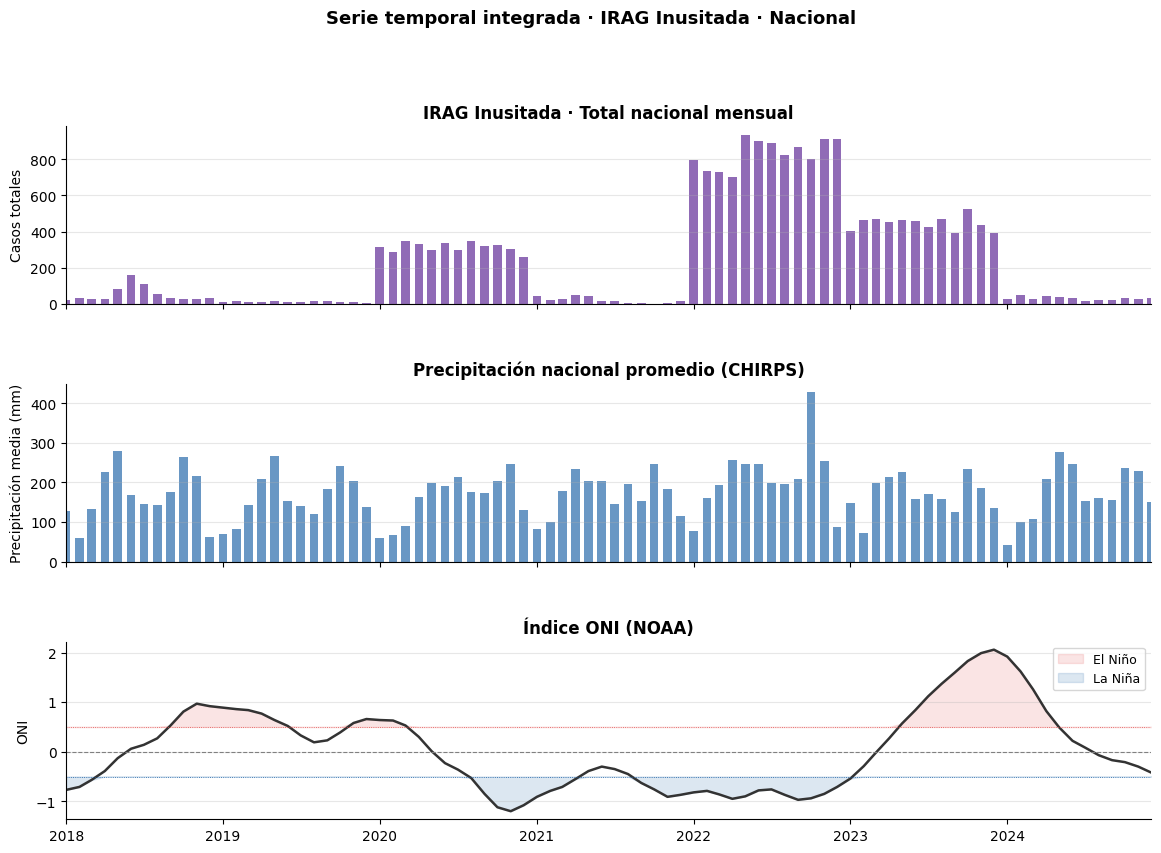

In [3]:
# Agregación nacional mensual
nacional = (
    df.groupby("date")
    .agg(
        casos_total    = ("casos",          "sum"),
        precip_media   = ("precip_mean_mm",  "mean"),
        oni            = ("value_oni",        "first"),
        fase_oni       = ("fase_oni",         "first"),
    )
    .reset_index()
    .sort_values("date")
)

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── IRAG ──────────────────────────────────────────────────────────────────
ax1.bar(nacional["date"], nacional["casos_total"],
        color=COLORES["irag"], alpha=0.75, width=20)
ax1.set_ylabel("Casos totales")
ax1.set_title("IRAG Inusitada · Total nacional mensual", fontweight="bold")
ax1.tick_params(labelbottom=False)

# ── Precipitación ─────────────────────────────────────────────────────────
ax2.bar(nacional["date"], nacional["precip_media"],
        color=COLORES["precip"], alpha=0.65, width=20)
ax2.set_ylabel("Precipitación media (mm)")
ax2.set_title("Precipitación nacional promedio (CHIRPS)", fontweight="bold")
ax2.tick_params(labelbottom=False)

# ── ONI ───────────────────────────────────────────────────────────────────
ax3.plot(nacional["date"], nacional["oni"],
         color=COLORES["oni"], linewidth=1.8)
ax3.axhline(0,    color="gray",            linewidth=0.8, linestyle="--")
ax3.axhline(0.5,  color=COLORES["nino"],   linewidth=0.6, linestyle=":")
ax3.axhline(-0.5, color=COLORES["nina"],   linewidth=0.6, linestyle=":")
ax3.fill_between(nacional["date"], 0.5,
                 nacional["oni"].clip(lower=0.5),
                 color=COLORES["nino"], alpha=0.15, label="El Niño")
ax3.fill_between(nacional["date"], -0.5,
                 nacional["oni"].clip(upper=-0.5),
                 color=COLORES["nina"], alpha=0.15, label="La Niña")
ax3.set_ylabel("ONI")
ax3.set_title("Índice ONI (NOAA)", fontweight="bold")
ax3.legend(fontsize=9, loc="upper right")

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(nacional["date"].min(), nacional["date"].max())
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Serie temporal integrada · IRAG Inusitada · Nacional",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3. Distribución espacial — top 20 municipios con más casos

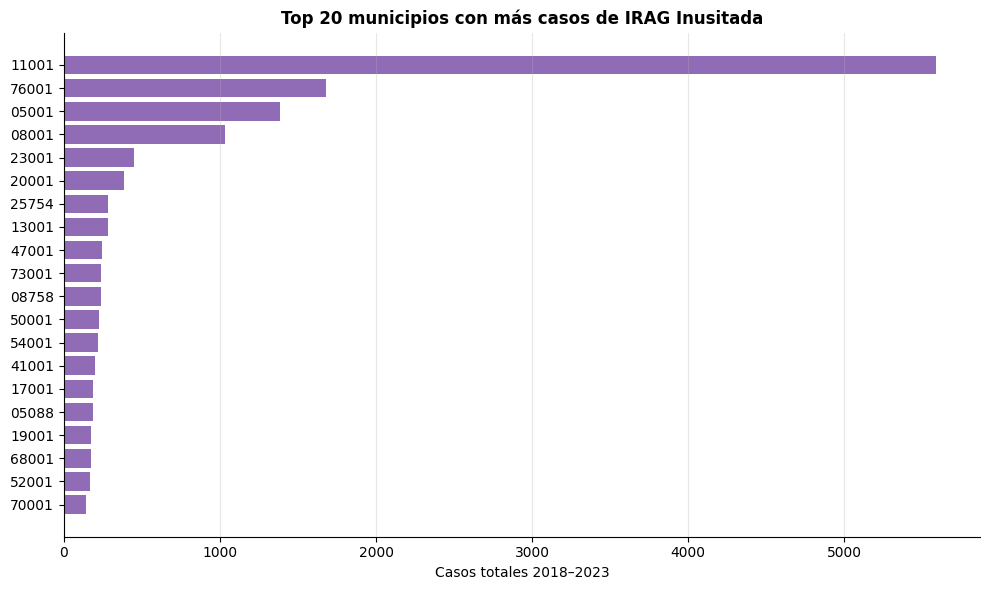


Top 20 municipios:
muni_code  casos
    11001   5590
    76001   1680
    05001   1382
    08001   1035
    23001    448
    20001    384
    25754    284
    13001    282
    47001    247
    73001    238
    08758    237
    50001    223
    54001    220
    41001    202
    17001    189
    05088    188
    19001    175
    68001    174
    52001    165
    70001    144

Estos 20 municipios concentran el 65.6% de los casos totales


In [4]:
top_munis = (
    df.groupby("muni_code")["casos"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_munis["muni_code"][::-1],
        top_munis["casos"][::-1],
        color=COLORES["irag"], alpha=0.75)
ax.set_xlabel("Casos totales 2018–2023")
ax.set_title("Top 20 municipios con más casos de IRAG Inusitada",
             fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 20 municipios:")
print(top_munis.to_string(index=False))
print(f"\nEstos 20 municipios concentran el "
      f"{top_munis['casos'].sum()/df['casos'].sum()*100:.1f}% de los casos totales")

## 4. Casos por fase ONI

Estadísticos de casos por fase ONI:
          total  media  mediana   desv      n
fase_oni                                     
El Niño    4875  0.161      0.0  2.834  30267
La Niña   12225  0.376      0.0  5.110  32509
Neutral    3452  0.110      0.0  1.978  31388


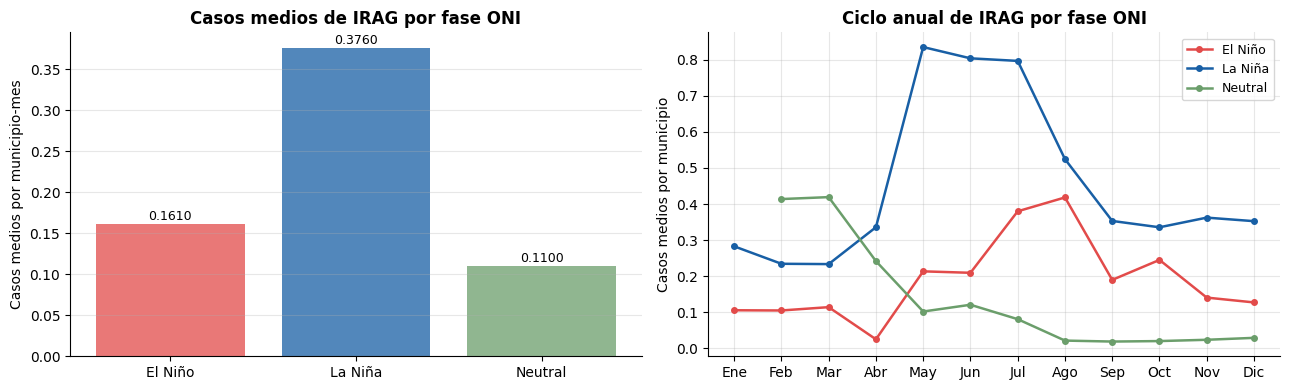

In [5]:
# Casos medios por municipio-mes según fase ONI
fase_stats = (
    df.groupby("fase_oni")["casos"]
    .agg(["sum", "mean", "median", "std", "count"])
    .rename(columns={"sum":"total","mean":"media",
                     "median":"mediana","std":"desv","count":"n"})
    .round(3)
)
print("Estadísticos de casos por fase ONI:")
print(fase_stats)

# Ciclo anual por fase ONI
ciclo = (
    df.groupby(["mes", "fase_oni"])["casos"]
    .mean()
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Barras por fase
fases = ["El Niño", "La Niña", "Neutral"]
colores_fases = [COLORES["nino"], COLORES["nina"], COLORES["neutral"]]
medias = [fase_stats.loc[f, "media"] if f in fase_stats.index else 0
          for f in fases]

ax1.bar(fases, medias, color=colores_fases, alpha=0.75)
ax1.set_ylabel("Casos medios por municipio-mes")
ax1.set_title("Casos medios de IRAG por fase ONI", fontweight="bold")
ax1.grid(axis="y", alpha=0.3)
for i, v in enumerate(medias):
    ax1.text(i, v + 0.001, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

# Ciclo anual por fase
for fase, color in zip(fases, colores_fases):
    sub = ciclo[ciclo["fase_oni"] == fase]
    if not sub.empty:
        ax2.plot(sub["mes"], sub["casos"],
                 marker="o", markersize=4,
                 color=color, linewidth=1.8, label=fase)

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(NOMBRES_MESES)
ax2.set_ylabel("Casos medios por municipio")
ax2.set_title("Ciclo anual de IRAG por fase ONI", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Relación visual precipitación vs casos

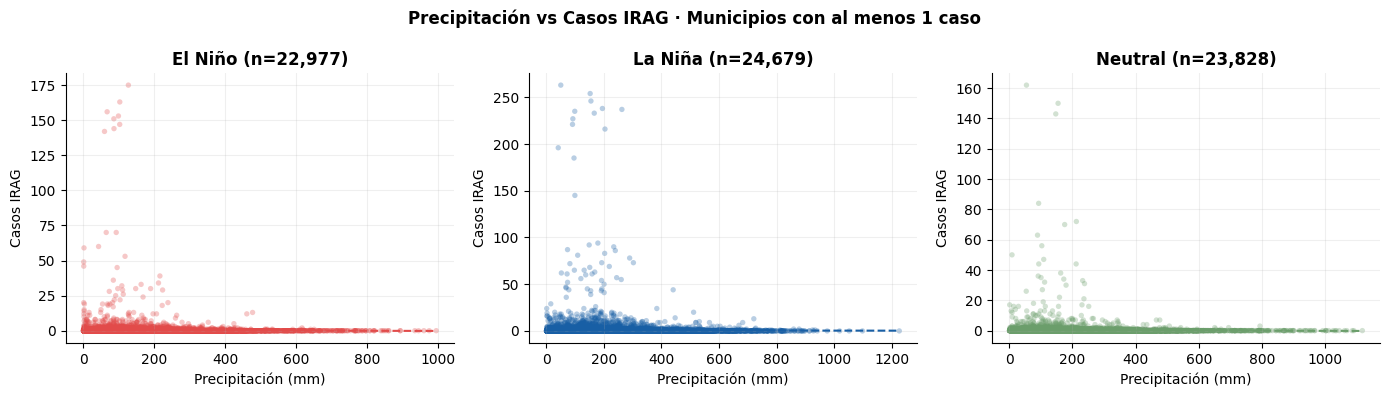

In [6]:
# Solo municipios con al menos un caso
df_con_casos = df[df["muni_code"].isin(
    df[df["casos"] > 0]["muni_code"].unique()
)].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    "Precipitación vs Casos IRAG · Municipios con al menos 1 caso",
    fontsize=12, fontweight="bold"
)

for ax, fase, color in zip(
    axes, ["El Niño", "La Niña", "Neutral"],
    [COLORES["nino"], COLORES["nina"], COLORES["neutral"]]
):
    sub = df_con_casos[df_con_casos["fase_oni"] == fase]
    if sub.empty:
        ax.set_title(f"{fase} (sin datos)")
        continue

    ax.scatter(
        sub["precip_mean_mm"], sub["casos"],
        color=color, alpha=0.3, s=15, edgecolors="none"
    )

    # Línea de tendencia
    mask = sub["precip_mean_mm"].notna() & sub["casos"].notna()
    if mask.sum() > 10:
        m, b = np.polyfit(
            sub.loc[mask, "precip_mean_mm"],
            sub.loc[mask, "casos"], 1
        )
        x_line = np.linspace(
            sub["precip_mean_mm"].min(),
            sub["precip_mean_mm"].max(), 100
        )
        ax.plot(x_line, m * x_line + b,
                color=color, linewidth=1.5, linestyle="--")

    ax.set_xlabel("Precipitación (mm)")
    ax.set_ylabel("Casos IRAG")
    ax.set_title(f"{fase} (n={len(sub):,})", fontweight="bold")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Verificación de calidad de datos

In [7]:
print("=" * 55)
print("VERIFICACIÓN DE CALIDAD")
print("=" * 55)

# Distribución de casos
print("\nDistribución de casos por registro:")
print(df["casos"].describe().round(3))

# Municipios con todos los meses en cero
munis_cero = (
    df.groupby("muni_code")["casos"]
    .sum()
    .eq(0)
    .sum()
)
print(f"\nMunicipios con cero casos en todo el período: {munis_cero}")
print(f"  (pueden ser ausencia real o subregistro del SIVIGILA)")

# Casos por año
print("\nCasos totales por año:")
print(df.groupby("anio")["casos"].sum().to_string())

# Valores extremos
top5 = df.nlargest(5, "casos")[["date","muni_code","casos","precip_mean_mm","value_oni"]]
print("\nTop 5 registros con más casos:")
print(top5.to_string(index=False))

print("\n✓ Verificación completada")

VERIFICACIÓN DE CALIDAD

Distribución de casos por registro:
count    94164.000
mean         0.218
std          3.594
min          0.000
25%          0.000
50%          0.000
75%          0.000
max        263.000
Name: casos, dtype: float64

Municipios con cero casos en todo el período: 270
  (pueden ser ausencia real o subregistro del SIVIGILA)

Casos totales por año:
anio
2018      637
2019      151
2020     3768
2021      251
2022    10016
2023     5354
2024      375

Top 5 registros con más casos:
      date muni_code  casos  precip_mean_mm  value_oni
2022-12-01     11001    263       50.469715      -0.71
2022-07-01     11001    254      152.452393      -0.76
2022-05-01     11001    246      155.190964      -0.90
2022-06-01     11001    238      194.990494      -0.78
2022-10-01     11001    237      262.690918      -0.94

✓ Verificación completada
